In [1]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [2]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None
       release_year
count   8807.000000
mean    2014.180198


In [3]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [4]:
df = df.dropna()

In [5]:
print(df.duplicated().sum())

0


In [7]:
Q1 = df["release_year"].quantile(0.25)
Q3 = df["release_year"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["release_year"] < lower) | (df["release_year"] > upper)]

print("Number of outliers:", len(outliers))

print(outliers[["title", "release_year"]])

Number of outliers: 473
                                    title  release_year
7                                 Sankofa          1993
24                                  Jeans          1998
41                                   Jaws          1975
42                                 Jaws 2          1978
43                                 Jaws 3          1983
...                                   ...           ...
8742                       Wild Wild West          1999
8745  Willy Wonka & the Chocolate Factory          1971
8748                 Winter of Our Dreams          1981
8764                           Wyatt Earp          1994
8792                          Young Tiger          1973

[473 rows x 2 columns]


In [9]:
df.columns = df.columns.str.lower()

In [11]:
df.columns = df.columns.str.strip()

In [12]:
df["duration_numeric"] = df["duration"].str.extract('(\d+)')

In [13]:
df["duration_numeric"] = pd.to_numeric(df["duration_numeric"])

In [14]:
df["director"] = df["director"].fillna("Unknown")

df["country"] = df["country"].fillna("Not Available")

In [15]:
df = df.drop_duplicates()

In [16]:
df.to_csv("cleaned_netflix_data.csv", index=False)

(5332, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5332 entries, 0 to 5331
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   show_id           5332 non-null   object
 1   type              5332 non-null   object
 2   title             5332 non-null   object
 3   director          5332 non-null   object
 4   cast              5332 non-null   object
 5   country           5332 non-null   object
 6   date_added        5332 non-null   object
 7   release_year      5332 non-null   int64 
 8   rating            5332 non-null   object
 9   duration          5332 non-null   object
 10  listed_in         5332 non-null   object
 11  description       5332 non-null   object
 12  duration_numeric  5332 non-null   int64 
dtypes: int64(2), object(11)
memory usage: 541.7+ KB
None
       release_year  duration_numeric
count   5332.000000       5332.000000
mean    2012.742123         99.922543
std        9.625831 

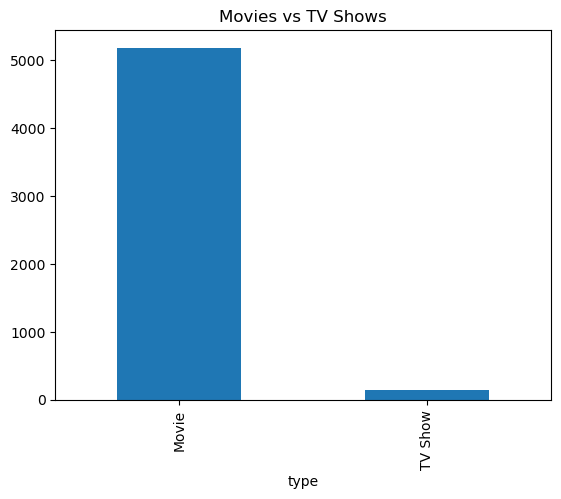

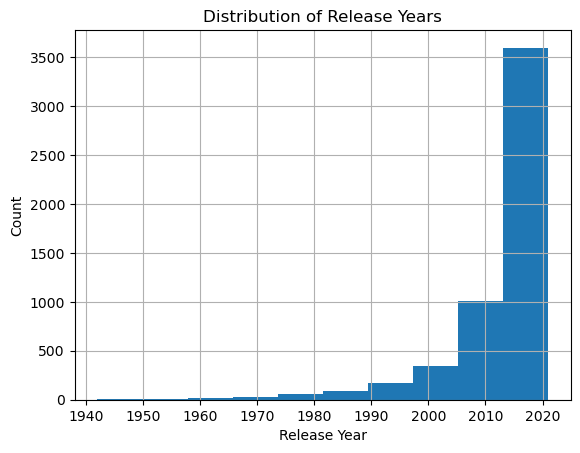

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("cleaned_netflix_data.csv")
df.head()
print(df.shape)
print(df.info())
print(df.describe())
df["type"].value_counts().plot(kind="bar")
plt.title("Movies vs TV Shows")
plt.show()
df["release_year"].hist()
plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()

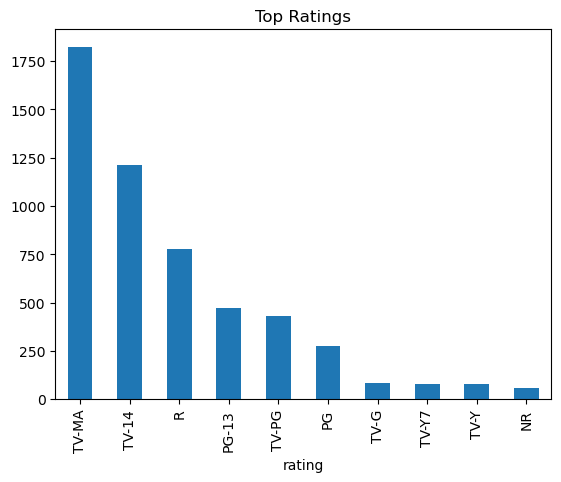

In [3]:
df["rating"].value_counts().head(10).plot(kind="bar")
plt.title("Top Ratings")
plt.show()

                  release_year  duration_numeric
release_year          1.000000         -0.220749
duration_numeric     -0.220749          1.000000


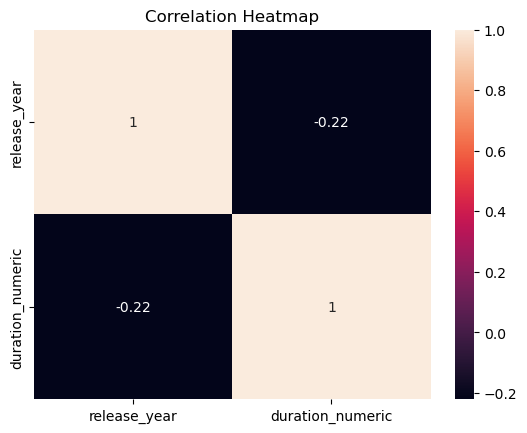

In [4]:
corr = df[["release_year", "duration_numeric"]].corr()
print(corr)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [1]:
import pandas as pd
from scipy.stats import ttest_ind
df = pd.read_csv("cleaned_netflix_data.csv")
movies = df[df["type"] == "Movie"]["duration_numeric"].dropna()
tvshows = df[df["type"] == "TV Show"]["duration_numeric"].dropna()
t_stat, p_value = ttest_ind(movies, tvshows, equal_var=False)
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 252.17899571706434
P-Value: 0.0
